<a href="https://colab.research.google.com/github/aoonging/BSC_DPDM2025/blob/main/uhdm_model2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# crop_hand

In [ ]:
!pip install -q ultralytics opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.1 MB/s eta 0:00:00a 0:00:01


In [ ]:
import shutil
from pathlib import Path

SRC = "/kaggle/input/datasets/boonyaratsenjan/crop-hand-yolo-py/crop_hand_yolo.py"  # แก้
shutil.copy(SRC, "/kaggle/working/crop_hand_yolo.py")
print("copied")

copied


In [ ]:
WEIGHTS = "/kaggle/input/datasets/boonyaratsenjan/detection-pt/detection.pt"
MOIRE_DIR = "/kaggle/input/datasets/boonyaratsenjan/datarnsa/dataRSNA/mobile"
CLEAN_DIR = "/kaggle/input/datasets/boonyaratsenjan/datarnsa/dataRSNA/imagesRSNA"
OUT_DIR = "/kaggle/working/hand_yolo_out"

!rm -rf {OUT_DIR}
!python /kaggle/working/crop_hand_yolo.py \
  --weights {WEIGHTS} \
  --moire_dir {MOIRE_DIR} \
  --clean_dir {CLEAN_DIR} \
  --out_dir {OUT_DIR} \
  --size 768 \
  --conf 0.25 \
  --pad_ratio 0.08

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
คู่รูปที่จับชื่อได้: 200
weights: /kaggle/input/datasets/boonyaratsenjan/detection-pt/detection.pt
[1/200] 1408: FAIL moire_conf= clean_conf=0.9582
[2/200] 1498: OK moire_conf=0.8656 clean_conf=0.9485
[3/200] 1560: FAIL moire_conf= clean_conf=0.9616
[4/200] 1602: FAIL moire_conf= clean_conf=0.9571
[5/200] 1708: FAIL moire_conf= clean_conf=0.9612
[6/200] 1715: FAIL moire_conf= clean_conf=0.9572
[7/200] 1743: FAIL moire_conf= clean_conf=0.954
[8/200] 1777: FAIL moire_conf= clean_conf=0.964
[9/200] 1784: FAIL moire_conf= clean_conf=0.9621
[10/200] 1807: FAIL moire_conf= clean_conf=0.9321
[11/200] 1848: OK moire_conf=0.9359 clean_conf=0.9532
[12/200] 1870: FAIL moire_conf= clean_conf=

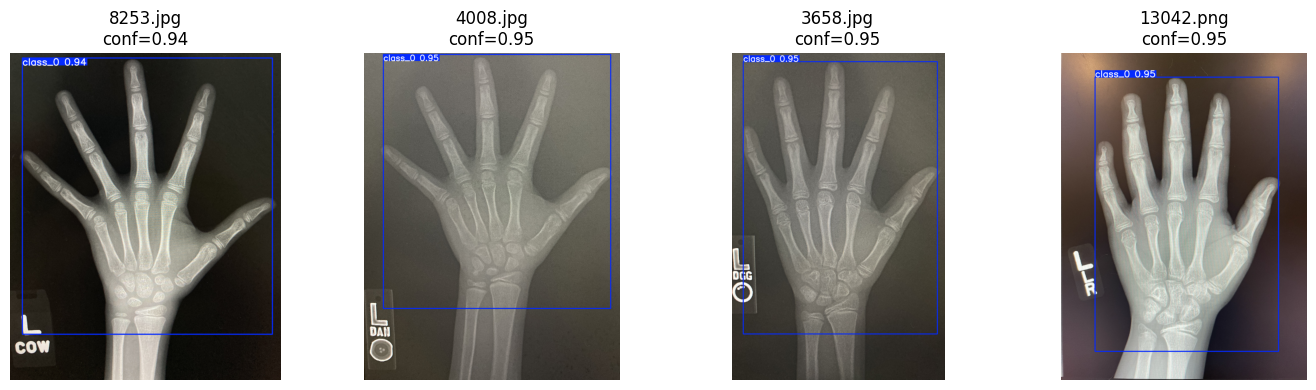

In [ ]:
from ultralytics import YOLO
import random, cv2, matplotlib.pyplot as plt
from pathlib import Path

model = YOLO(WEIGHTS)

moire_dir = Path(MOIRE_DIR)   # แปลงเป็น Path
files = list(moire_dir.glob("*.png")) + list(moire_dir.glob("*.jpg"))
paths = random.sample(files, min(4, len(files)))

fig, axes = plt.subplots(1, len(paths), figsize=(3.5*len(paths), 4))
if len(paths) == 1: axes = [axes]

for ax, p in zip(axes, paths):
    r = model.predict(str(p), conf=0.25, verbose=False)[0]
    img = r.plot()[:, :, ::-1]
    conf = float(r.boxes.conf.max()) if r.boxes is not None and len(r.boxes) else 0
    ax.imshow(img)
    ax.set_title(f"{p.name}\nconf={conf:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
df = pd.read_csv("/kaggle/working/hand_yolo_out/crop_yolo_report.csv")
fail = df[df["ok"] == 0]
print("FAIL:", len(fail))
print(fail[["name", "moire_conf", "clean_conf"]].head(20))

FAIL: 28
    name  moire_conf  clean_conf
0   1408         NaN      0.9582
2   1560         NaN      0.9616
3   1602         NaN      0.9571
4   1708         NaN      0.9612
5   1715         NaN      0.9572
6   1743         NaN      0.9540
7   1777         NaN      0.9640
8   1784         NaN      0.9621
9   1807         NaN      0.9321
11  1870         NaN      0.9546
12  1901         NaN      0.9553
13  1968         NaN      0.9566
14  2013         NaN      0.9662
15  2023         NaN      0.9113
16  2165         NaN      0.9548
17  2266         NaN      0.9548
18  2282         NaN      0.9515
19  2283         NaN      0.9504
21  2370         NaN      0.9666
23  2505         NaN      0.9518


showing: ['1498', '1848', '2306', '2414', '10838', '14752', '5935', '9621', '15199', '15397', '15580', '15603']


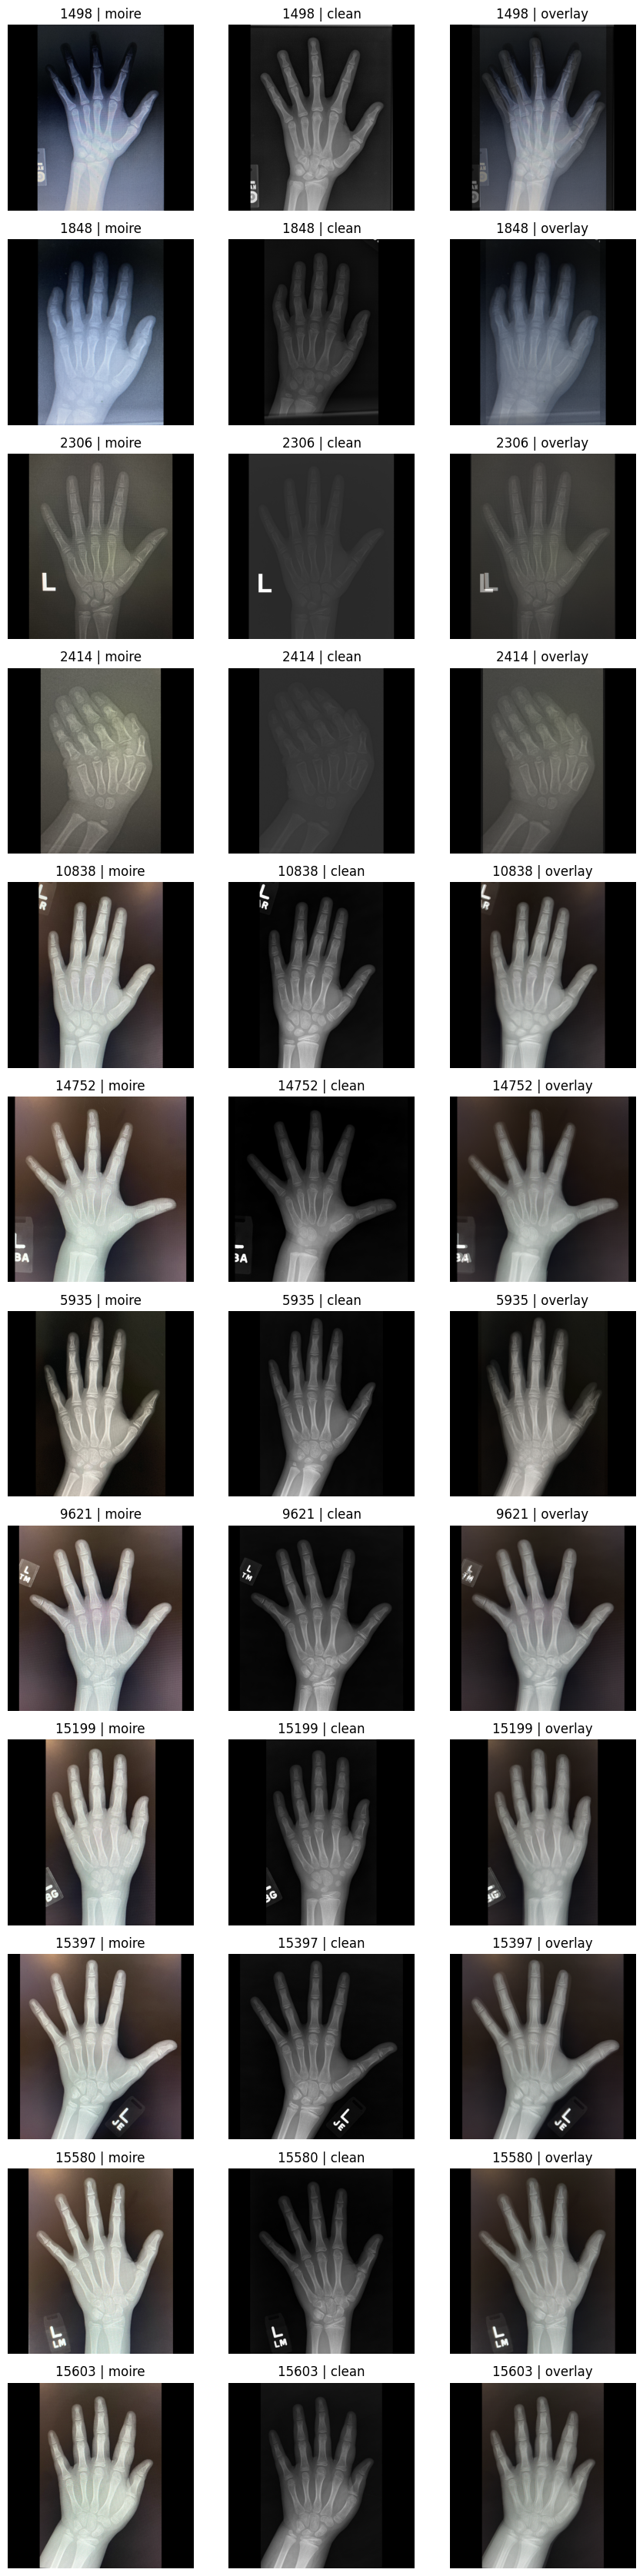

In [ ]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

OUT = Path("/kaggle/working/hand_yolo_out")
all_names = sorted(
    [p.stem for p in (OUT / "overlay").glob("*.png")],
    key=lambda x: int(x) if x.isdigit() else x
)

# เอา 4 ใบแรก + 4 ใบท้าย + สุ่มกลางอีก 4 ใบ
head = all_names[:4]
tail = all_names[-4:]
mid_pool = all_names[4:-4] if len(all_names) > 8 else []
mid = random.sample(mid_pool, min(4, len(mid_pool))) if mid_pool else []

names = head + mid + tail
# กันชื่อซ้ำถ้าชุดเล็ก
names = list(dict.fromkeys(names))

print("showing:", names)

n = len(names)
fig, axes = plt.subplots(n, 3, figsize=(9, 2.8 * n))
if n == 1:
    axes = [axes]

for i, stem in enumerate(names):
    for j, sub in enumerate(["moire", "clean", "overlay"]):
        axes[i][j].imshow(Image.open(OUT / sub / f"{stem}.png"))
        axes[i][j].set_title(f"{stem} | {sub}")
        axes[i][j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!cd /kaggle/working && zip -r hand_yolo_out.zip hand_yolo_out
!ls -lh /kaggle/working/hand_yolo_out.zip

from IPython.display import FileLink
FileLink("/kaggle/working/hand_yolo_out.zip")

  adding: hand_yolo_out/ (stored 0%)
  adding: hand_yolo_out/crop_yolo_report.csv (deflated 65%)
  adding: hand_yolo_out/bbox_preview/ (stored 0%)
  adding: hand_yolo_out/bbox_preview/7979_clean.png (deflated 19%)
  adding: hand_yolo_out/bbox_preview/13565_moire.png (deflated 8%)
  adding: hand_yolo_out/bbox_preview/11974_moire.png (deflated 7%)
  adding: hand_yolo_out/bbox_preview/13528_clean.png (deflated 21%)
  adding: hand_yolo_out/bbox_preview/2611_moire.png (deflated 6%)
  adding: hand_yolo_out/bbox_preview/12420_moire.png (deflated 8%)
  adding: hand_yolo_out/bbox_preview/14634_moire.png (deflated 8%)
  adding: hand_yolo_out/bbox_preview/9974_moire.png (deflated 8%)
  adding: hand_yolo_out/bbox_preview/4359_moire.png (deflated 9%)
  adding: hand_yolo_out/bbox_preview/3937_moire.png (deflated 12%)
  adding: hand_yolo_out/bbox_preview/9621_moire.png (deflated 9%)
  adding: hand_yolo_out/bbox_preview/6821_moire.png (deflated 6%)
  adding: hand_yolo_out/bbox_preview/5994_moire.png (

/kaggle/working/hand_yolo_out.zip

# UHDM Project

In [ ]:
!pip install -q pyyaml tensorboardX lpips thop scikit-image opencv-python-headless tqdm pillow

import os, shutil
from pathlib import Path

SRC_UHDM = "/kaggle/input/datasets/boonyaratsenjan/uhdm12/UHDM"  # แก้ถ้าชื่อ dataset ต่าง
WORK = Path("/kaggle/working/UHDM")

if WORK.exists():
    shutil.rmtree(WORK)
shutil.copytree(SRC_UHDM, WORK)
os.chdir(WORK)

print("cwd:", os.getcwd())
print("ckpt:", Path("uhdm_checkpoint.pth").exists())
print("crop out:", Path("/kaggle/working/hand_yolo_out/moire").exists())

cwd: /kaggle/working/UHDM
ckpt: True
crop out: True


In [ ]:
MOIRE = "/kaggle/working/hand_yolo_out/moire"   # มี moiré
CLEAN = "/kaggle/working/hand_yolo_out/clean"   # ไม่มี moiré
DATA  = "/kaggle/working/finetune_data"

!python scripts/prepare_uhdm_finetune_data.py \
  --moire_dir {MOIRE} \
  --clean_dir {CLEAN} \
  --out_dir {DATA} \
  --size 768 \
  --val_ratio 0.15

!ls {DATA}/Train | head

คู่ทั้งหมด: 172
Train: 147 | Val/Test: 25
เสร็จแล้ว: /kaggle/working/finetune_data
  Train/  -> ชี้ TRAIN_DATASET มาที่นี่
  Test/   -> ชี้ TEST_DATASET มาที่นี่
  id_map.csv
0001_gt.jpg
0001_moire.jpg
0002_gt.jpg
0002_moire.jpg
0003_gt.jpg
0003_moire.jpg
0004_gt.jpg
0004_moire.jpg
0005_gt.jpg
0005_moire.jpg


In [ ]:
yaml_text = """
GENERAL:
  GPU_ID: 0
  SEED: 123
  WORKER: 2
  SAVE_PREFIX: '/kaggle/working/out_dir/hand_finetune'
  EXP_NAME: 'exp_ft'

DATA:
  DATA_TYPE: UHDM
  TRAIN_DATASET: '/kaggle/working/finetune_data/Train'
  TEST_DATASET: '/kaggle/working/finetune_data/Test'

MODEL:
  EN_FEATURE_NUM: 48
  EN_INTER_NUM: 32
  DE_FEATURE_NUM: 64
  DE_INTER_NUM: 32
  SAM_NUMBER: 1

TRAIN:
  BATCH_SIZE: 2
  LOADER: crop
  CROP_SIZE: 512
  RESIZE_SIZE: 512
  SAVE_ITER: 200
  LOAD_EPOCH: False
  PRETRAIN_PATH: '/kaggle/working/UHDM/uhdm_checkpoint.pth'
  LAM: 1
  LAM_P: 1

TEST:
  TEST_EPOCH: auto
  SAVE_IMG: False
  LOAD_PATH: False
  EVALUATION_METRIC: True
  EVALUATION_TIME: False
  EVALUATION_COST: False

SOLVER:
  EPOCHS: 50
  T_0: 20
  T_MULT: 1
  ETA_MIN: 0.000001
  BASE_LR: 0.00005
"""

Path("config/finetune_hand_config.yaml").write_text(yaml_text)
print("saved config")

saved config


In [ ]:
from pathlib import Path

p = Path("/kaggle/working/UHDM/utils/common.py")
text = p.read_text()

# ลบของเก่าที่พัง แล้วใส่ชุดที่ถูก
start = text.find("def __init__(self, optimizer, T_0, T_mult=1, eta_min=0, last_epoch=-1, verbose=False):")
end = text.find("def get_lr(self):", start)
assert start != -1 and end != -1, "หาฟังก์ชันไม่เจอ"

fixed = '''def __init__(self, optimizer, T_0, T_mult=1, eta_min=0, last_epoch=-1, verbose=False):
        if T_0 <= 0 or not isinstance(T_0, int):
            raise ValueError("Expected positive integer T_0, but got {}".format(T_0))
        if T_mult < 1 or not isinstance(T_mult, int):
            raise ValueError("Expected integer T_mult >= 1, but got {}".format(T_mult))
        self.T_0 = T_0
        self.T_i = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.verbose = verbose

        self.T_cur = 0 if last_epoch < 0 else last_epoch
        # PyTorch ใหม่ไม่รับ verbose ใน LRScheduler.__init__
        try:
            super(CosineAnnealingWarmRestarts, self).__init__(optimizer, last_epoch, verbose)
        except TypeError:
            super(CosineAnnealingWarmRestarts, self).__init__(optimizer, last_epoch)

    '''

text = text[:start] + fixed + text[end:]
p.write_text(text)

# เช็ก syntax
compile(text, str(p), "exec")
print("patched + syntax ok")

patched + syntax ok


In [ ]:
# ต้องเปิด GPU (T4)
!python train.py --config ./config/finetune_hand_config.yaml

Loading pretrained weights from /kaggle/working/UHDM/uhdm_checkpoint.pth
Pretrained weights loaded. Start fine-tuning...
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
****start traininig!!!****
Training  : Epoch 1, lr 0.0000500, Avg. Loss = 1.93909: 100%|█| 73/73 [00:57<00: 
Training  : Epoch 2, lr 0.0000497, Avg. Loss = 1.79832: 100%|█| 73/73 [00:41<00: 
Training  : Epoch 3, lr 0.0000488, Avg. Loss = 1.76373: 100%|█| 73/73 [

In [ ]:
!ls -lh /kaggle/working/out_dir/hand_finetune/exp_ft/net_checkpoints/
!cd /kaggle/working && zip -r hand_finetune_ckpt.zip out_dir/hand_finetune/exp_ft/net_checkpoints

from IPython.display import FileLink
FileLink("/kaggle/working/hand_finetune_ckpt.zip")

total 410M
-rw-r--r-- 1 root root 69M Jul 13 13:15 checkpoint_000010.tar
-rw-r--r-- 1 root root 69M Jul 13 13:22 checkpoint_000020.tar
-rw-r--r-- 1 root root 69M Jul 13 13:29 checkpoint_000030.tar
-rw-r--r-- 1 root root 69M Jul 13 13:36 checkpoint_000040.tar
-rw-r--r-- 1 root root 69M Jul 13 13:42 checkpoint_000050.tar
-rw-r--r-- 1 root root 69M Jul 13 13:42 checkpoint_latest.tar
updating: out_dir/hand_finetune/exp_ft/net_checkpoints/ (stored 0%)
  adding: out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_000010.tar (deflated 13%)
  adding: out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_000050.tar (deflated 13%)
  adding: out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_latest.tar (deflated 13%)
  adding: out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_000040.tar (deflated 13%)
  adding: out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_000030.tar (deflated 13%)
  adding: out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_000020.tar (deflated 14

/kaggle/working/hand_finetune_ckpt.zip

In [ ]:
%cd /kaggle/working/UHDM
from pathlib import Path

# ใส่รูปที่มี moiré (ใช้ชุด Test ที่เตรียมไว้)
TEST_MOIRE = Path("/kaggle/working/finetune_data/Test")
# สร้างโฟลเดอร์เฉพาะไฟล์ *_moire.jpg ให้ demo อ่าน
demo_in = Path("/kaggle/working/demo_in")
demo_in.mkdir(parents=True, exist_ok=True)
for p in TEST_MOIRE.glob("*_moire.jpg"):
    (demo_in / p.name).write_bytes(p.read_bytes())

yaml_text = f"""
GENERAL:
  GPU_ID: 0
  SEED: 123
  WORKER: 0
  SAVE_PREFIX: '/kaggle/working/demo_dir/ft'
  EXP_NAME: 'exp'

DATA:
  DEMO_DATASET: '{demo_in}'

MODEL:
  EN_FEATURE_NUM: 48
  EN_INTER_NUM: 32
  DE_FEATURE_NUM: 64
  DE_INTER_NUM: 32
  SAM_NUMBER: 1

TEST:
  SAVE_IMG: jpg
  LOAD_PATH: '/kaggle/working/out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_latest.tar'
"""
Path("demo_config/demo_ft.yaml").write_text(yaml_text)
!python demo_test.py --config ./demo_config/demo_ft.yaml

/kaggle/working
Using device: cuda:0
2026-07-13 13:48:02.642837
load model from /kaggle/working/out_dir/hand_finetune/exp_ft/net_checkpoints/checkpoint_latest.tar
save image results to /kaggle/working/demo_dir/ft/exp/test_result/customer
save logger to /kaggle/working/demo_dir/ft/exp/test_result/customer_result.log
Test demo: 100%|████████████████████████████████| 25/25 [00:08<00:00,  3.07it/s]


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
จำนวนรูปที่ประเมิน: 25
PSNR ↑ เฉลี่ย: 23.323 dB
SSIM ↑ เฉลี่ย: 0.7841
LPIPS ↓ เฉลี่ย: 0.2646


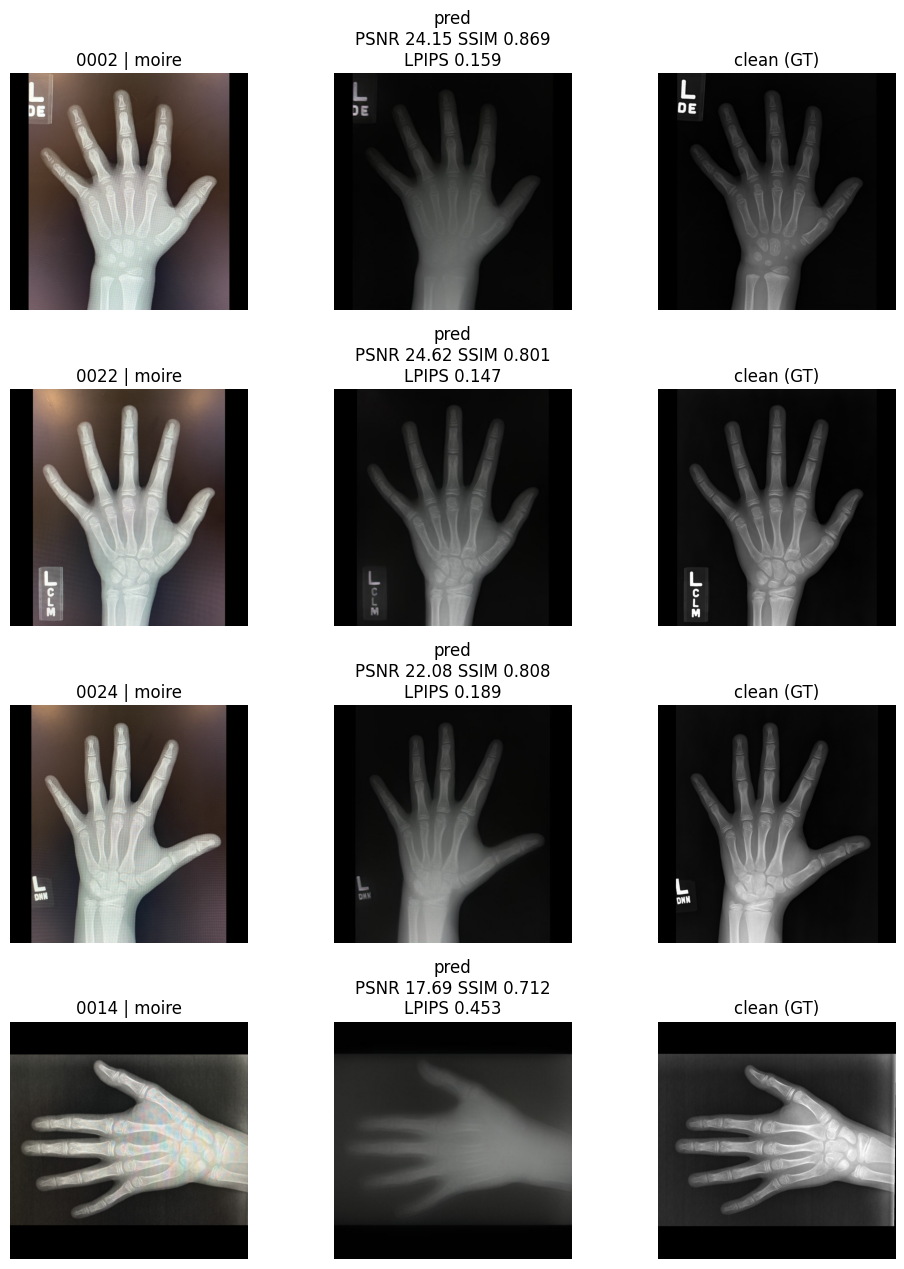

In [ ]:
import random
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import lpips

GT_DIR = Path("/kaggle/working/finetune_data/Test")
PRED_DIR = Path("/kaggle/working/demo_dir/ft/exp/test_result/customer")

# จับคู่: 0001_moire.jpg → pred test_0001_moire.jpg , gt 0001_gt.jpg
pairs = []
for gt in sorted(GT_DIR.glob("*_gt.jpg")):
    uid = gt.name.replace("_gt.jpg", "")
    pred = PRED_DIR / f"test_{uid}_moire.jpg"
    if pred.exists():
        pairs.append((uid, GT_DIR / f"{uid}_moire.jpg", pred, gt))

assert pairs, "ยังไม่มีรูปผลลัพธ์ หรือชื่อไฟล์ไม่ตรง"

device = "cuda" if torch.cuda.is_available() else "cpu"
lpips_fn = lpips.LPIPS(net="alex").to(device)

def to_float(img_path):
    arr = np.asarray(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
    return arr

rows = []
for uid, moire_p, pred_p, gt_p in pairs:
    moire, pred, gt = map(to_float, [moire_p, pred_p, gt_p])
    # บังคับขนาดเท่ากันเผื่อต่างนิดหน่อย
    h = min(moire.shape[0], pred.shape[0], gt.shape[0])
    w = min(moire.shape[1], pred.shape[1], gt.shape[1])
    moire, pred, gt = moire[:h, :w], pred[:h, :w], gt[:h, :w]

    p = psnr(gt, pred, data_range=1.0)
    s = ssim(gt, pred, channel_axis=2, data_range=1.0)

    t_pred = torch.from_numpy(pred).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    t_gt = torch.from_numpy(gt).permute(2, 0, 1).unsqueeze(0).to(device) * 2 - 1
    l = float(lpips_fn(t_pred, t_gt).item())

    rows.append((uid, moire, pred, gt, p, s, l))

print(f"จำนวนรูปที่ประเมิน: {len(rows)}")
print(f"PSNR ↑ เฉลี่ย: {np.mean([r[4] for r in rows]):.3f} dB")
print(f"SSIM ↑ เฉลี่ย: {np.mean([r[5] for r in rows]):.4f}")
print(f"LPIPS ↓ เฉลี่ย: {np.mean([r[6] for r in rows]):.4f}")

# สุ่มโชว์ 4 รูป
show = random.sample(rows, min(4, len(rows)))
fig, axes = plt.subplots(len(show), 3, figsize=(10, 3.2 * len(show)))
if len(show) == 1:
    axes = [axes]

for i, (uid, moire, pred, gt, p, s, l) in enumerate(show):
    axes[i][0].imshow(moire); axes[i][0].set_title(f"{uid} | moire"); axes[i][0].axis("off")
    axes[i][1].imshow(pred); axes[i][1].set_title(f"pred\nPSNR {p:.2f} SSIM {s:.3f}\nLPIPS {l:.3f}"); axes[i][1].axis("off")
    axes[i][2].imshow(gt); axes[i][2].set_title("clean (GT)"); axes[i][2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import shutil

GT_DIR = Path("/kaggle/working/finetune_data/Test")
PRED_DIR = Path("/kaggle/working/demo_dir/ft/exp/test_result/customer")
OUT_DIR = Path("/kaggle/working/vis_compare")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ลบของเก่าก่อน (ถ้ามี)
for p in OUT_DIR.glob("*.jpg"):
    p.unlink()

pairs = []
for gt in sorted(GT_DIR.glob("*_gt.jpg")):
    uid = gt.name.replace("_gt.jpg", "")
    pred = PRED_DIR / f"test_{uid}_moire.jpg"
    moire = GT_DIR / f"{uid}_moire.jpg"
    if pred.exists() and moire.exists():
        pairs.append((uid, moire, pred, gt))

def make_strip(uid, moire_p, pred_p, gt_p, out_path):
    imgs = [Image.open(p).convert("RGB") for p in (moire_p, pred_p, gt_p)]
    # บังคับสูงเท่ากัน
    h = min(im.height for im in imgs)
    imgs = [
        im.resize((int(im.width * h / im.height), h), Image.Resampling.LANCZOS)
        for im in imgs
    ]
    gap, label_h = 8, 36
    w = sum(im.width for im in imgs) + gap * 2
    canvas = Image.new("RGB", (w, h + label_h), (255, 255, 255))
    draw = ImageDraw.Draw(canvas)
    labels = ["moire", "pred", "clean"]
    x = 0
    for im, lab in zip(imgs, labels):
        canvas.paste(im, (x, label_h))
        draw.text((x + 8, 8), f"{uid} | {lab}", fill=(0, 0, 0))
        x += im.width + gap
    canvas.save(out_path, quality=95)

for uid, moire, pred, gt in pairs:
    make_strip(uid, moire, pred, gt, OUT_DIR / f"{uid}_compare.jpg")

# zip ให้โหลดง่าย
zip_path = Path("/kaggle/working/vis_compare.zip")
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive(str(zip_path.with_suffix("")), "zip", OUT_DIR)

print(f"เซฟแล้ว {len(pairs)} รูปที่: {OUT_DIR}")
print(f"ดาวน์โหลด: {zip_path}")
!ls -lh /kaggle/working/vis_compare.zip
!ls /kaggle/working/vis_compare | head

เซฟแล้ว 25 รูปที่: /kaggle/working/vis_compare
ดาวน์โหลด: /kaggle/working/vis_compare.zip
-rw-r--r-- 1 root root 6.7M Jul 13 13:53 /kaggle/working/vis_compare.zip
0001_compare.jpg
0002_compare.jpg
0003_compare.jpg
0004_compare.jpg
0005_compare.jpg
0006_compare.jpg
0007_compare.jpg
0008_compare.jpg
0009_compare.jpg
0010_compare.jpg
